In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"          # single GPU — avoids DataParallel OOM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!pip install -q -U "transformers>=4.50" "datasets>=2.20" accelerate sentencepiece rouge_score sacrebleu evaluate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.1 MB/s eta 0:00:00


## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
from huggingface_hub import login
from getpass import getpass

# Colab only -- no Kaggle secrets fallback needed here
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    HF_TOKEN = getpass("Enter your HuggingFace token (input hidden): ")

login(HF_TOKEN)
print("Logged in to HuggingFace")

Enter your HuggingFace token (input hidden): ··········
Logged in to HuggingFace


In [4]:
import torch, gc
for _name in ("model", "base_only"):
    try:
        del globals()[_name]
    except KeyError:
        pass
gc.collect(); torch.cuda.empty_cache()

## Config

**This version runs on Google Colab with data on Google Drive, not Kaggle:**
- Drive is mounted above at `/content/drive`.
- `DATA_PATH` must point at wherever you actually uploaded `wambaza_training_data_final.csv`
  in your Drive — update the placeholder path below.
- All outputs (`eval_scores.csv`, prediction CSVs, native-review bundles) now save to
  `SAVE_DIR` in Drive instead of `/kaggle/working/`, so they persist after the Colab runtime
  disconnects instead of disappearing.
- `FT_MODEL_ID` points to `DianePretty/Wambaza_2.0` on the Hub — a merged, standalone model
  (confirmed via the model card: safetensors, 1.0B params, no adapter files). No `PeftModel`
  / adapter-merging step is needed.
- `BASE_MODEL` is `google/gemma-3-1b-it` to match Wambaza_2.0's size (1B) for a fair
  before/after comparison — swap this if you evaluate the 4B model later.
- `EVAL_LANGS` is `["kin", "lug"]` only — English and Swahili are excluded from this run.

**⚠️ Caveat worth knowing before you trust these numbers:** this script has no record of the
*exact* held-out split used when Wambaza_2.0 was originally trained (that training notebook
isn't the one in this project's history — Wambaza_2.0 predates it). Below, a fixed-seed 15%
holdout is reconstructed from the current data pool per language. If Wambaza_2.0's original
training run used a different seed or split logic, some of these "held-out" questions may
actually have been seen during training, which would inflate scores. If you still have the
original train/test split file from when Wambaza_2.0 was trained, use that instead — it would
be strictly more trustworthy than this reconstruction.

In [5]:
FT_MODEL_ID = "DianePretty/Wambaza_No_Swahili"
BASE_MODEL  = "google/gemma-3-1b-it"     # same size as Wambaza_2.0, for a fair before/after
COMPARE_TO_BASE = True

# Update this to match wherever the CSV actually sits in your Drive.
DATA_PATH = "/content/drive/MyDrive/wambaza_training_data.csv"

# Optional: loss curve needs a trainer_state.json from your training checkpoint -- deployed
# HF repos usually don't include this. Leave the path wrong/missing and that cell just skips.
TRAINER_STATE_JSON = "/content/drive/MyDrive/checkpoint-1500/trainer_state.json"

SAVE_DIR = "/content/drive/MyDrive/wambaza_eval_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

EVAL_LANGS = ["kin", "lug", "en"]     # order matters -- kin, lug, en is the requested display order
LANG_DISPLAY = {"kin": "Kinyarwanda", "lug": "Luganda", "en": "English"}

SEED = 42
MAX_NEW_TOKENS = 200
PER_LANG_EVAL_CAP = 60   # cut further for runtime -- 60/lang x 3 langs x 2 models = 360 generations

print(f"Data path: {DATA_PATH}  (exists: {os.path.exists(DATA_PATH)})")
print(f"Save dir : {SAVE_DIR}")
print(f"Eval languages, in display order: {[LANG_DISPLAY[l] for l in EVAL_LANGS]}")

Data path: /content/drive/MyDrive/wambaza_training_data.csv  (exists: True)
Save dir : /content/drive/MyDrive/wambaza_eval_outputs
Eval languages, in display order: ['Kinyarwanda', 'Luganda', 'English']


## Plotting setup

Charts are saved to `SAVE_DIR/figures` so they persist in Drive and can be pulled directly into the report.

In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 150, "font.size": 11,
                             "axes.spines.top": False, "axes.spines.right": False})

FIG_DIR = f"{SAVE_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = f"{FIG_DIR}/{name}.png"
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

## Reconstruct the held-out eval set

See the caveat above about split provenance.

In [7]:
import pandas as pd, re, numpy as np

df = pd.read_csv(DATA_PATH)
print("Full file:", df.shape)
print(df["lang"].value_counts())

def clean(t):
    t = str(t)
    t = re.sub(r"as of my last (knowledge update|update)", "", t, flags=re.IGNORECASE)
    return re.sub(r"\s{2,}", " ", t).strip()

df["question"] = df["question"].map(clean)
df["answer"]   = df["answer"].map(clean)
df = df[(df["question"] != "") & (df["answer"] != "")]
df = df.drop_duplicates(subset=["lang", "question", "answer"]).reset_index(drop=True)

data = df[df["lang"].isin(EVAL_LANGS)].reset_index(drop=True)
print("\nFiltered pool (Kinyarwanda + Luganda + English):")
print(data["lang"].value_counts())

Full file: (19249, 4)
lang
en     7833
kin    7582
lug    3834
Name: count, dtype: int64

Filtered pool (Kinyarwanda + Luganda + English):
lang
en     7831
kin    7581
lug    3834
Name: count, dtype: int64


Saved: /content/drive/MyDrive/wambaza_eval_outputs/figures/data_language_distribution.png


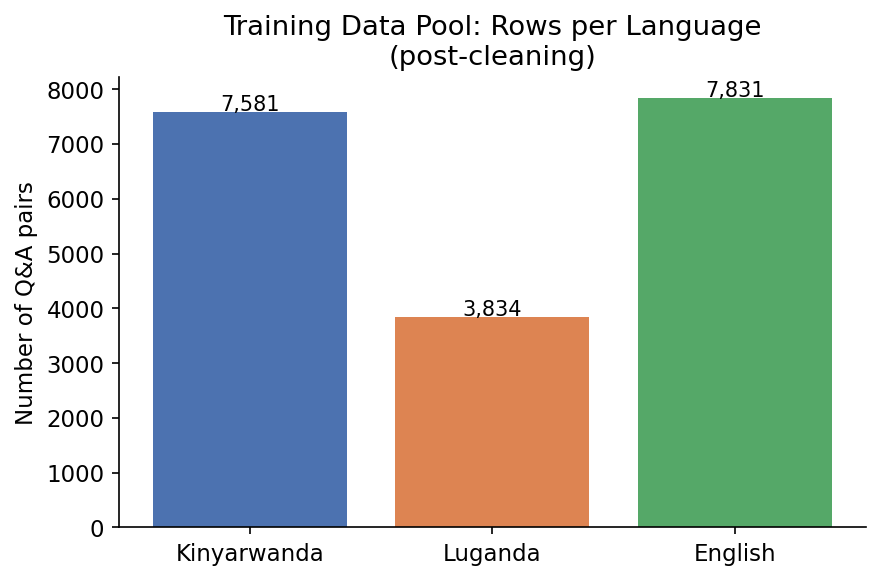

In [8]:
# Language distribution in the filtered pool, ordered kin -> lug -> en (not by frequency)
LANG_COLORS = {"kin": "#4C72B0", "lug": "#DD8452", "en": "#55A868"}
counts = data["lang"].value_counts().reindex(EVAL_LANGS)
plt.figure(figsize=(6, 4))
bars = plt.bar([LANG_DISPLAY.get(l, l) for l in counts.index],
               counts.values,
               color=[LANG_COLORS.get(l, "#999999") for l in counts.index])
plt.title("Training Data Pool: Rows per Language\n(post-cleaning)")
plt.ylabel("Number of Q&A pairs")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 30, f"{int(b.get_height()):,}",
              ha="center", fontsize=10)
savefig("data_language_distribution")

In [9]:
# Fixed-seed 15% holdout per language — see caveat in the config cell above re: split provenance
eval_parts = []
for lang in EVAL_LANGS:
    sub = data[data["lang"] == lang]
    eval_parts.append(sub.sample(frac=0.15, random_state=SEED))
eval_set = pd.concat(eval_parts, ignore_index=True).reset_index(drop=True)

print("Reconstructed eval set:")
print(eval_set["lang"].value_counts())
print(f"Total: {len(eval_set)}")

if PER_LANG_EVAL_CAP:
    eval_set = eval_set.groupby("lang", group_keys=False).apply(
        lambda g: g.sample(min(PER_LANG_EVAL_CAP, len(g)), random_state=SEED)
    ).reset_index(drop=True)
    print(f"\nCapped to {PER_LANG_EVAL_CAP}/language for this run:")
    print(eval_set["lang"].value_counts())

Reconstructed eval set:
lang
en     1175
kin    1137
lug     575
Name: count, dtype: int64
Total: 2887

Capped to 60/language for this run:
lang
en     60
kin    60
lug    60
Name: count, dtype: int64


/tmp/ipykernel_1746/4019796090.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eval_set = eval_set.groupby("lang", group_keys=False).apply(


## Load the fine-tuned model

`Wambaza_2.0` is a merged, standalone model — loaded directly, no adapter, no quantization
config needed (1B fits comfortably in bf16 on a T4).

In [10]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    FT_MODEL_ID, torch_dtype=torch.bfloat16, device_map={"": 0}, attn_implementation="eager",
)
model.config.use_cache = True
model.eval()

eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
eos_id = tokenizer.eos_token_id
stop_ids = [t for t in {eot_id, eos_id} if t is not None]
print("Stop token ids:", stop_ids)

config.json:   0%|          | 0.00/1.78k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.00GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/210 [00:00<?, ?B/s]

Stop token ids: [1, 106]


Token length stats (question + answer, n=500 sample):
  median = 153
  mean   = 181.3
  95th percentile = 388
  max    = 522
Saved: /content/drive/MyDrive/wambaza_eval_outputs/figures/token_length_distribution.png


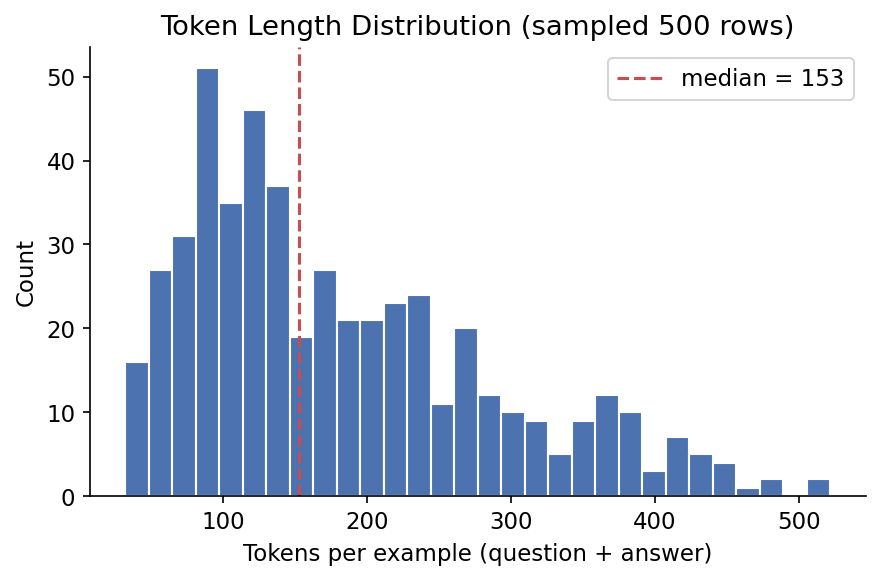

In [11]:
# Token length distribution (justifies MAX_SEQ_LEN choice during training)
def n_tokens_text(q, a):
    msgs = [{"role":"user","content":q},{"role":"assistant","content":a}]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
    return len(tokenizer(text).input_ids)

sample_for_lens = data.sample(min(500, len(data)), random_state=SEED)
lens = sample_for_lens.apply(lambda r: n_tokens_text(r["question"], r["answer"]), axis=1)

print("Token length stats (question + answer, n={} sample):".format(len(sample_for_lens)))
print(f"  median = {int(lens.median())}")
print(f"  mean   = {lens.mean():.1f}")
print(f"  95th percentile = {int(lens.quantile(0.95))}")
print(f"  max    = {int(lens.max())}")

plt.figure(figsize=(6,4))
plt.hist(lens, bins=30, color="#4C72B0", edgecolor="white")
plt.axvline(lens.median(), color="#C44E52", linestyle="--", label=f"median = {int(lens.median())}")
plt.title("Token Length Distribution (sampled 500 rows)")
plt.xlabel("Tokens per example (question + answer)")
plt.ylabel("Count")
plt.legend()
savefig("token_length_distribution")

Loss summary:
  final training loss = 0.3294 (step 1500)
  final eval loss     = 0.6157 (step 1500)
  best eval loss      = 0.6157 (step 1500)

Full eval loss by step:
  step 150: 1.9359
  step 300: 1.5068
  step 450: 1.2503
  step 600: 1.0702
  step 750: 0.9384
  step 900: 0.8398
  step 1050: 0.7380
  step 1200: 0.6712
  step 1350: 0.6374
  step 1500: 0.6157
Saved: /content/drive/MyDrive/wambaza_eval_outputs/figures/training_loss_curve.png


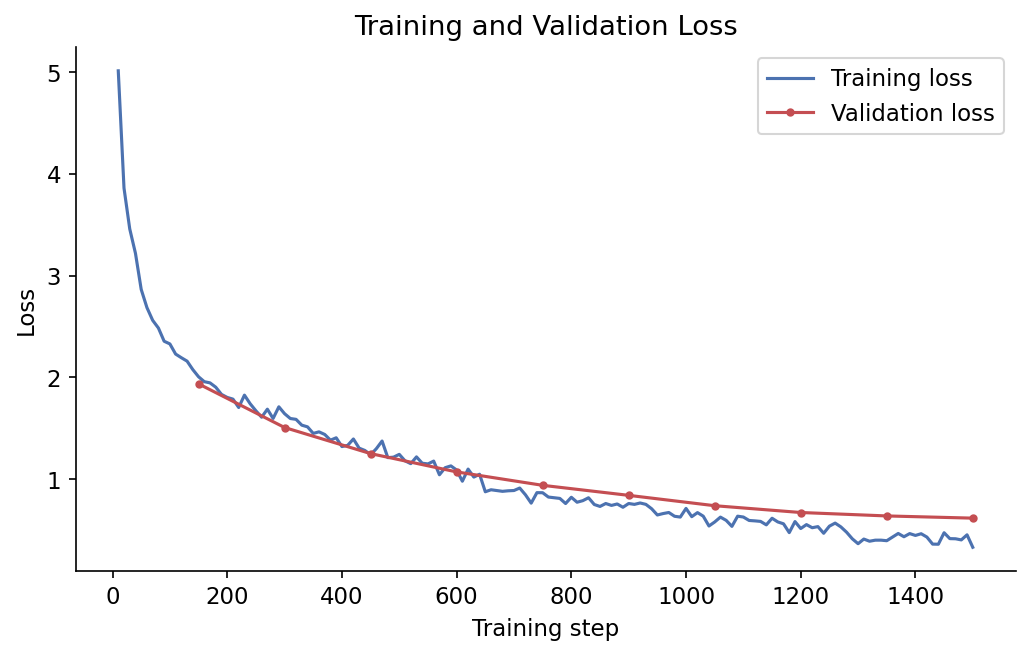

In [12]:
# Training and validation loss curve, with printed numbers (not just the chart)
import json as _json

if TRAINER_STATE_JSON and os.path.exists(TRAINER_STATE_JSON):
    state = _json.load(open(TRAINER_STATE_JSON))
    log = state.get("log_history", [])
    train_steps = [e["step"] for e in log if "loss" in e]
    train_loss  = [e["loss"] for e in log if "loss" in e]
    eval_steps  = [e["step"] for e in log if "eval_loss" in e]
    eval_loss   = [e["eval_loss"] for e in log if "eval_loss" in e]

    print("Loss summary:")
    if train_loss:
        print(f"  final training loss = {train_loss[-1]:.4f} (step {train_steps[-1]})")
    if eval_loss:
        print(f"  final eval loss     = {eval_loss[-1]:.4f} (step {eval_steps[-1]})")
        best_idx = eval_loss.index(min(eval_loss))
        print(f"  best eval loss      = {eval_loss[best_idx]:.4f} (step {eval_steps[best_idx]})")
    print("\nFull eval loss by step:")
    for s, l in zip(eval_steps, eval_loss):
        print(f"  step {s}: {l:.4f}")

    plt.figure(figsize=(7,4.5))
    if train_steps:
        plt.plot(train_steps, train_loss, label="Training loss", color="#4C72B0")
    if eval_steps:
        plt.plot(eval_steps, eval_loss, label="Validation loss", color="#C44E52", marker="o", markersize=3)
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    savefig("training_loss_curve")
else:
    print("TRAINER_STATE_JSON not set or not found -- skipping loss-curve figure.")
    print("This is optional: deployed HF repos usually don't include training internals.")

In [13]:
@torch.no_grad()
def ask(model_, tok_, question, max_new_tokens=MAX_NEW_TOKENS):
    prompt = tok_.apply_chat_template([{"role": "user", "content": question}],
                                      tokenize=False, add_generation_prompt=True)
    inputs = tok_(prompt, return_tensors="pt").to(model_.device)
    out = model_.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=False,
        repetition_penalty=1.3, no_repeat_ngram_size=3,
        eos_token_id=stop_ids, pad_token_id=tok_.pad_token_id or tok_.eos_token_id,
    )
    return tok_.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

## Generate predictions (fine-tuned model)

In [14]:
preds = []
for i, row in eval_set.iterrows():
    preds.append(ask(model, tokenizer, row["question"]))
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(eval_set)}")

eval_set["prediction"] = preds
print("Done generating with fine-tuned model.")

  20/180
  40/180
  60/180
  80/180
  100/180
  120/180
  140/180
  160/180
  180/180
Done generating with fine-tuned model.


## Generate predictions (base, untuned model)

Same questions, same stop tokens, no fine-tuning — for a clean before/after comparison.

In [15]:
if COMPARE_TO_BASE:
    del model
    gc.collect(); torch.cuda.empty_cache()

    base_tok = AutoTokenizer.from_pretrained(BASE_MODEL)
    base_only = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, torch_dtype=torch.bfloat16, device_map={"": 0}, attn_implementation="eager",
    )
    base_only.config.use_cache = True
    base_only.eval()

    base_eot = base_tok.convert_tokens_to_ids("<end_of_turn>")
    base_stop_ids_list = [t for t in {base_eot, base_tok.eos_token_id} if t is not None]

    @torch.no_grad()
    def ask_base(question, max_new_tokens=MAX_NEW_TOKENS):
        prompt = base_tok.apply_chat_template([{"role": "user", "content": question}],
                                              tokenize=False, add_generation_prompt=True)
        inputs = base_tok(prompt, return_tensors="pt").to(base_only.device)
        out = base_only.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            repetition_penalty=1.3, no_repeat_ngram_size=3,
            eos_token_id=base_stop_ids_list,
            pad_token_id=base_tok.pad_token_id or base_tok.eos_token_id,
        )
        return base_tok.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

    base_preds = []
    for i, row in eval_set.iterrows():
        base_preds.append(ask_base(row["question"]))
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(eval_set)}")
    eval_set["prediction_base"] = base_preds
    print("Done generating with base (untuned) model.")
else:
    print("Skipped base-model comparison (COMPARE_TO_BASE=False).")

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 33.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.00GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

  20/180
  40/180
  60/180
  80/180
  100/180
  120/180
  140/180
  160/180
  180/180
Done generating with base (untuned) model.


## Score: ROUGE + chrF, per language and overall

In [16]:
import evaluate
rouge = evaluate.load("rouge")
chrf  = evaluate.load("chrf")

def score(preds, refs):
    r = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    c = chrf.compute(predictions=preds, references=[[x] for x in refs])
    return {"ROUGE-1": round(r["rouge1"]*100,2), "ROUGE-2": round(r["rouge2"]*100,2),
            "ROUGE-L": round(r["rougeL"]*100,2), "chrF": round(c["score"],2)}

rows = []
for lang in EVAL_LANGS:
    sub = eval_set[eval_set["lang"] == lang]
    if len(sub) == 0: continue
    s = score(sub["prediction"].tolist(), sub["answer"].tolist())
    s.update({"lang": LANG_DISPLAY[lang], "model": "fine-tuned", "n": len(sub)})
    rows.append(s)

overall = score(eval_set["prediction"].tolist(), eval_set["answer"].tolist())
overall.update({"lang": "ALL", "model": "fine-tuned", "n": len(eval_set)})
rows.append(overall)

if COMPARE_TO_BASE:
    for lang in EVAL_LANGS:
        sub = eval_set[eval_set["lang"] == lang]
        if len(sub) == 0: continue
        s = score(sub["prediction_base"].tolist(), sub["answer"].tolist())
        s.update({"lang": LANG_DISPLAY[lang], "model": "base (untuned)", "n": len(sub)})
        rows.append(s)
    overall_base = score(eval_set["prediction_base"].tolist(), eval_set["answer"].tolist())
    overall_base.update({"lang": "ALL", "model": "base (untuned)", "n": len(eval_set)})
    rows.append(overall_base)

results = pd.DataFrame(rows)[["model","lang","n","ROUGE-1","ROUGE-2","ROUGE-L","chrF"]]

# Requested order: kin -> lug -> en -> ALL, not alphabetical (alphabetical would put
# "ALL"/"English" before "Kinyarwanda", which isn't what was asked for).
_lang_order = [LANG_DISPLAY[l] for l in EVAL_LANGS] + ["ALL"]
results["_lang_sort"] = results["lang"].map({name: i for i, name in enumerate(_lang_order)})
results = results.sort_values(["_lang_sort", "model"]).drop(columns="_lang_sort").reset_index(drop=True)

print(results.to_string(index=False))
results.to_csv(f"{SAVE_DIR}/eval_scores.csv", index=False)

         model        lang   n  ROUGE-1  ROUGE-2  ROUGE-L  chrF
base (untuned) Kinyarwanda  60     2.78     0.12     2.33 18.53
    fine-tuned Kinyarwanda  60    13.41     1.35     7.80 30.97
base (untuned)     Luganda  60     0.94     0.05     0.82 14.43
    fine-tuned     Luganda  60    10.62     0.74     6.37 29.68
base (untuned)     English  60    26.37     4.20    13.27 34.13
    fine-tuned     English  60    30.25     7.64    17.22 36.00
base (untuned)         ALL 180    10.07     1.45     5.44 22.83
    fine-tuned         ALL 180    18.05     3.25    10.42 32.25


Saved: /content/drive/MyDrive/wambaza_eval_outputs/figures/rouge1_base_vs_finetuned.png


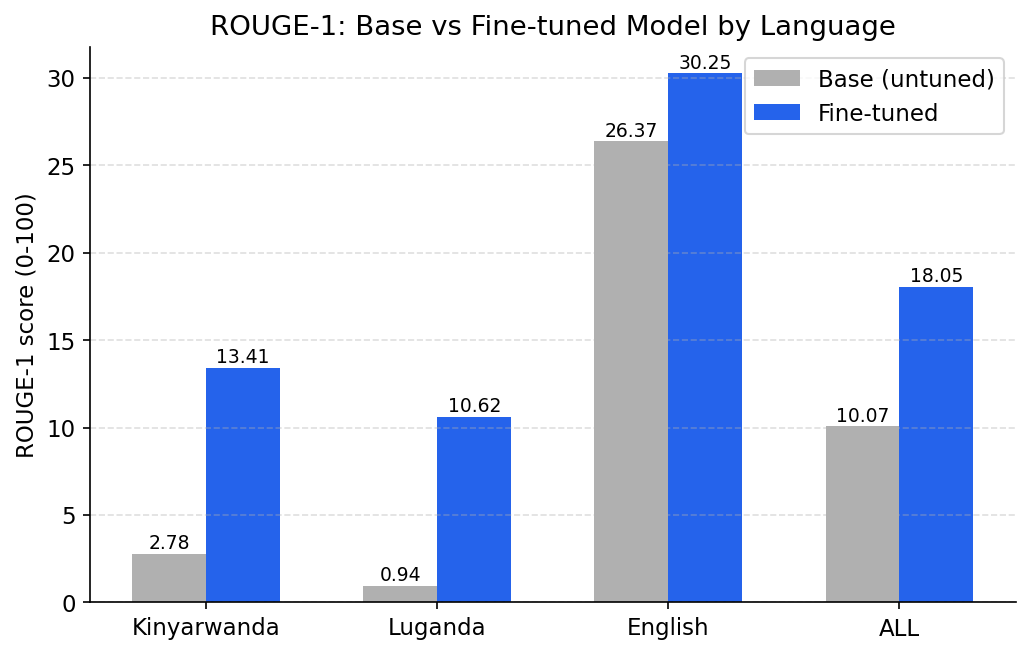

Saved: /content/drive/MyDrive/wambaza_eval_outputs/figures/chrf_base_vs_finetuned.png


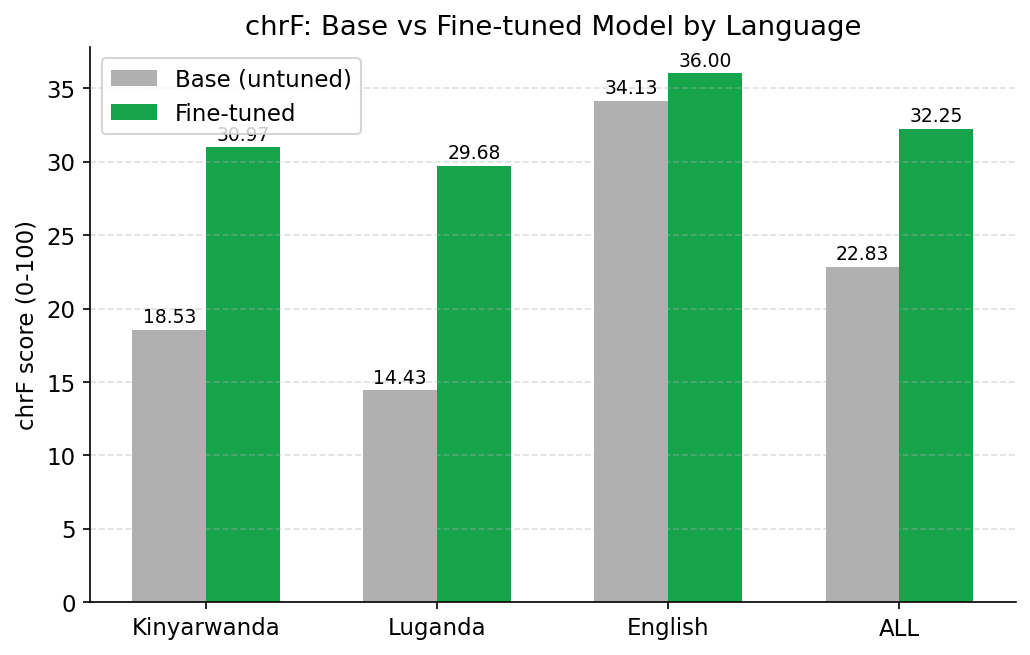

Saved: /content/drive/MyDrive/wambaza_eval_outputs/figures/finetuned_metrics_by_language.png


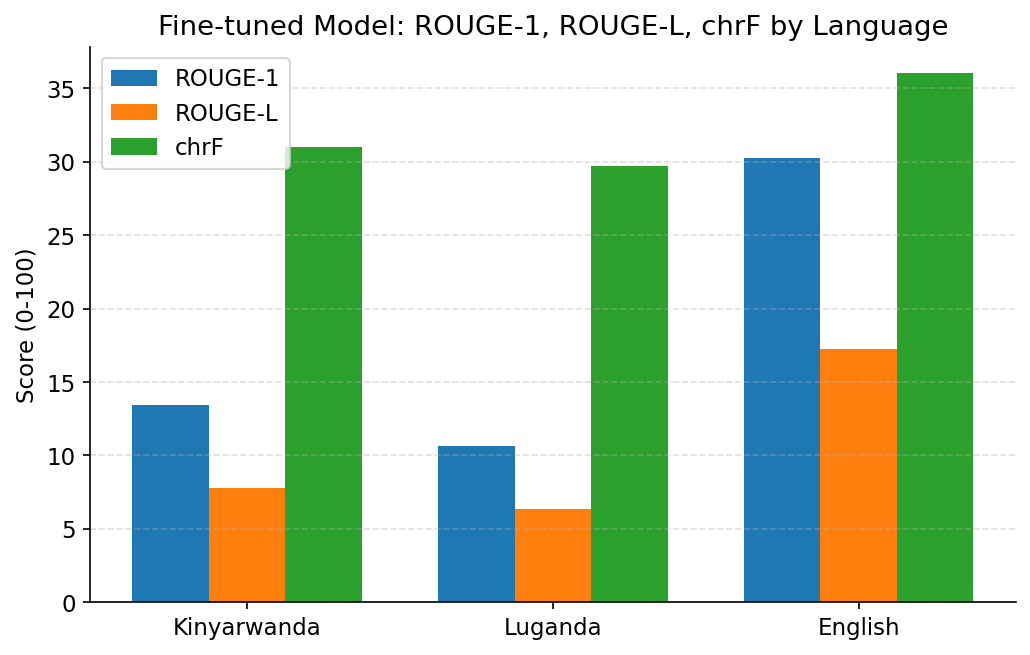

Saved: /content/drive/MyDrive/wambaza_eval_outputs/figures/rougeL_overall_vs_per_language.png


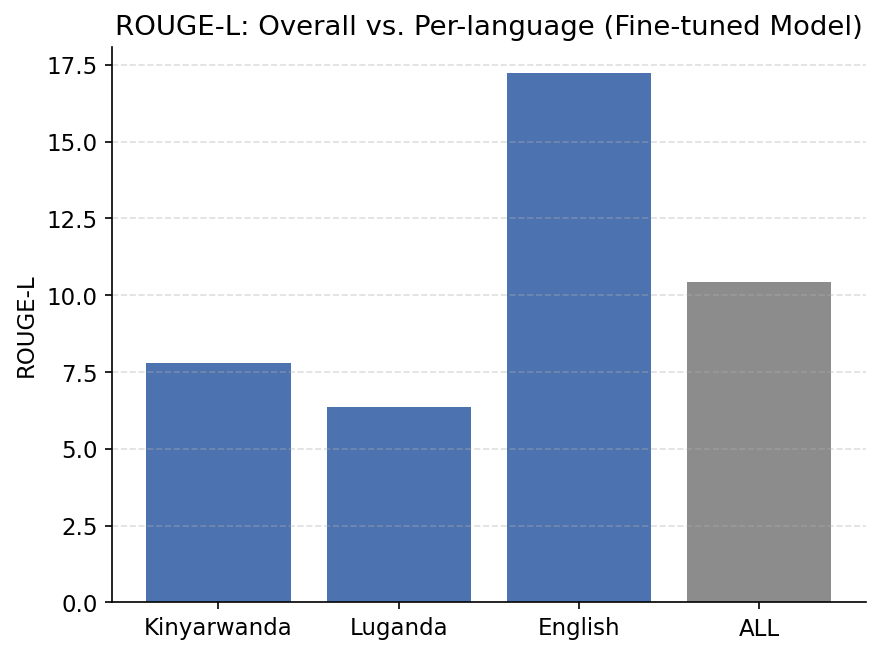

In [17]:
# --- Chart 1: ROUGE-1, base vs fine-tuned, by language ---
plot_langs = [l for l in EVAL_LANGS] + ["ALL"]
display_labels = [LANG_DISPLAY.get(l, l) for l in EVAL_LANGS] + ["ALL"]

ft_rows   = results[results["model"] == "fine-tuned"].set_index("lang")
base_rows = results[results["model"] == "base (untuned)"].set_index("lang") if COMPARE_TO_BASE else None

def get_val(df, lang_key, metric):
    row_lang = LANG_DISPLAY.get(lang_key, lang_key) if lang_key != "ALL" else "ALL"
    return df.loc[row_lang, metric]

if COMPARE_TO_BASE:
    x = range(len(plot_langs))
    width = 0.32
    base_vals = [get_val(base_rows, l, "ROUGE-1") for l in plot_langs]
    ft_vals   = [get_val(ft_rows, l, "ROUGE-1") for l in plot_langs]

    plt.figure(figsize=(7, 4.5))
    plt.bar([xi - width/2 for xi in x], base_vals, width, label="Base (untuned)", color="#b0b0b0")
    plt.bar([xi + width/2 for xi in x], ft_vals, width, label="Fine-tuned", color="#2563eb")
    plt.xticks(list(x), display_labels)
    plt.ylabel("ROUGE-1 score (0-100)")
    plt.title("ROUGE-1: Base vs Fine-tuned Model by Language")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    for xi, v in zip(x, base_vals):
        plt.text(xi - width/2, v + 0.3, f"{v:.2f}", ha="center", fontsize=9)
    for xi, v in zip(x, ft_vals):
        plt.text(xi + width/2, v + 0.3, f"{v:.2f}", ha="center", fontsize=9)
    savefig("rouge1_base_vs_finetuned")

    # --- Chart 2: chrF, base vs fine-tuned, by language ---
    base_vals = [get_val(base_rows, l, "chrF") for l in plot_langs]
    ft_vals   = [get_val(ft_rows, l, "chrF") for l in plot_langs]

    plt.figure(figsize=(7, 4.5))
    plt.bar([xi - width/2 for xi in x], base_vals, width, label="Base (untuned)", color="#b0b0b0")
    plt.bar([xi + width/2 for xi in x], ft_vals, width, label="Fine-tuned", color="#16a34a")
    plt.xticks(list(x), display_labels)
    plt.ylabel("chrF score (0-100)")
    plt.title("chrF: Base vs Fine-tuned Model by Language")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    for xi, v in zip(x, base_vals):
        plt.text(xi - width/2, v + 0.5, f"{v:.2f}", ha="center", fontsize=9)
    for xi, v in zip(x, ft_vals):
        plt.text(xi + width/2, v + 0.5, f"{v:.2f}", ha="center", fontsize=9)
    savefig("chrf_base_vs_finetuned")

# --- Chart 3: ROUGE-1/ROUGE-L/chrF grouped bar, fine-tuned only, per language ---
plot_df = results[(results["model"] == "fine-tuned") & (results["lang"] != "ALL")]
metrics = ["ROUGE-1", "ROUGE-L", "chrF"]
x = range(len(plot_df))
width = 0.25

plt.figure(figsize=(7, 4.5))
for i, m in enumerate(metrics):
    plt.bar([xi + i*width for xi in x], plot_df[m], width=width, label=m)
plt.xticks([xi + width for xi in x], plot_df["lang"].tolist())
plt.ylabel("Score (0-100)")
plt.title("Fine-tuned Model: ROUGE-1, ROUGE-L, chrF by Language")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
savefig("finetuned_metrics_by_language")

# --- Chart 4: Overall vs per-language ROUGE-L, fine-tuned only ---
plt.figure(figsize=(6, 4.5))
ft_only = results[results["model"] == "fine-tuned"]
colors = ["#8C8C8C" if l == "ALL" else "#4C72B0" for l in ft_only["lang"]]
plt.bar(ft_only["lang"], ft_only["ROUGE-L"], color=colors)
plt.ylabel("ROUGE-L")
plt.title("ROUGE-L: Overall vs. Per-language (Fine-tuned Model)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
savefig("rougeL_overall_vs_per_language")

## Read the actual outputs, not just the scores

This is the important step. Aggregate metrics cannot tell fluent-but-wrong apart
from correct-but-differently-phrased — especially for Kinyarwanda and Luganda.

In [18]:
cols = ["lang","question","answer","prediction"]
if COMPARE_TO_BASE: cols.append("prediction_base")

eval_set[cols].to_csv(f"{SAVE_DIR}/eval_predictions_full.csv", index=False)

for lang in EVAL_LANGS:
    sub = eval_set[eval_set["lang"] == lang].head(3)
    for _, row in sub.iterrows():
        print(f"=== {LANG_DISPLAY[lang]} ===")
        print("Q        :", row["question"][:150])
        print("REF      :", row["answer"][:200])
        print("FINE-TUNE:", row["prediction"][:200])
        if COMPARE_TO_BASE:
            print("BASE     :", row["prediction_base"][:200])
        print("-"*70)

=== Kinyarwanda ===
Q        : Uretse Virusi itera SIDA, izindi ndwara zandurira mu mibonano mpuzabitsina ni izihe?
REF      : Izindi ndwara zandurira mu mibonano mpuzabitsina harimo Syphilis, Gonorrhea, Herpes, Chlamydia, Trichomoniasis, Hepatitis B
FINE-TUNE: Virusi ya VIH (Human Immunodeficiency Virus) ishobora kwirakwiriye cyane n'izindi ngombwa zo guhura igitambaro no gukwirinda ubucuri bwo kurwanya indwara. Izi ngomba kugufasha abantu kugaragaza ko bag
BASE     : Iye ureketsa virusa HIV (Infectioni ya Virusu ya AIDS) yasiya nazi za zandura. Iyi kwayala:

*   **Zandura:** Zandura inakubwa na virus *HIV*, vuli kuwasaidia kupata viereza vya AIDS. Ni virus cha nyi
----------------------------------------------------------------------
=== Kinyarwanda ===
Q        : Ese nshobora kubwira inshuti zanjye ibibazo mfite ku birebana n'ubuzima bw'imyororokere nta nkomyi?
REF      : Ni koko, kuganira n'incuti bishobora kugufasha, ariko ujye ureba neza ko na zo zibimenya!
FINE-TUNE: Ibyo biterw

## Native-speaker review bundles

Same two-tier structure as before: this is what actually validates whether the model is
*correct*, not just fluent — one file per language, for a native speaker to hand-score.

In [19]:
kin_review = eval_set[eval_set["lang"] == "kin"][cols]
kin_review.to_csv(f"{SAVE_DIR}/kin_native_review.csv", index=False)

lug_review = eval_set[eval_set["lang"] == "lug"][cols]
lug_review.to_csv(f"{SAVE_DIR}/lug_native_review.csv", index=False)

en_review = eval_set[eval_set["lang"] == "en"][cols]
en_review.to_csv(f"{SAVE_DIR}/en_native_review.csv", index=False)

print(f"Saved {len(kin_review)} Kinyarwanda rows -> kin_native_review.csv")
print(f"Saved {len(lug_review)} Luganda rows -> lug_native_review.csv")
print(f"Saved {len(en_review)} English rows -> en_native_review.csv")

print(f"\nAll outputs saved to {SAVE_DIR}:")
print("  eval_scores.csv              (ROUGE/chrF summary table)")
print("  eval_predictions_full.csv    (every prediction, all languages)")
print("  kin_native_review.csv        (Kinyarwanda only, for native-speaker review)")
print("  lug_native_review.csv        (Luganda only, for native-speaker review)")
print("  en_native_review.csv         (English only, for reviewer sanity-check)")

Saved 60 Kinyarwanda rows -> kin_native_review.csv
Saved 60 Luganda rows -> lug_native_review.csv
Saved 60 English rows -> en_native_review.csv

All outputs saved to /content/drive/MyDrive/wambaza_eval_outputs:
  eval_scores.csv              (ROUGE/chrF summary table)
  eval_predictions_full.csv    (every prediction, all languages)
  kin_native_review.csv        (Kinyarwanda only, for native-speaker review)
  lug_native_review.csv        (Luganda only, for native-speaker review)
  en_native_review.csv         (English only, for reviewer sanity-check)
